**Three Outliers | 2023**
# Penyisihan MLC - Data Slayer 1.0: Prediksi Emisi CO2 pada Kendaraan Beroda Empat
*Eduardus Tjitrahardja, Ikhlasul Akmal Hanif, and Bryan Tjandra*


  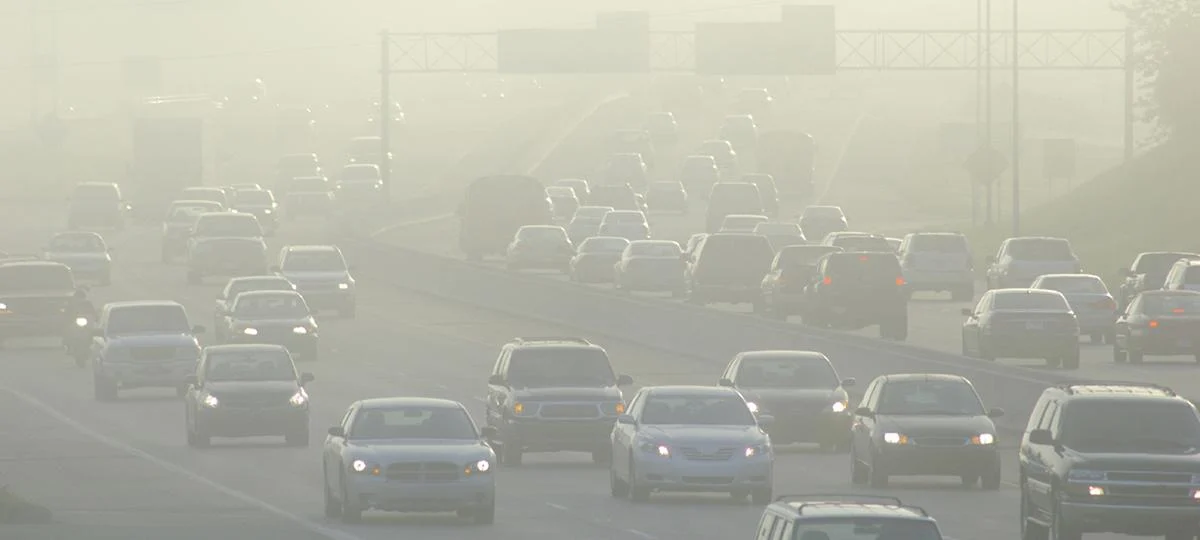

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from tqdm import tqdm
import pickle

import catboost as cb
from scipy.spatial.distance import euclidean


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import math

from autogluon.tabular import TabularPredictor
from autogluon.tabular.models.knn.knn_rapids_model import KNNRapidsModel
from autogluon.tabular.models.lr.lr_rapids_model import LinearRapidsModel
import shap
shap.initjs()
import autogluon.eda.auto as auto

In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')


## HELPER

In [ ]:
MPG_IMP_TO_L_PER_100KM = 282.481
MPG_AS_TO_L_PER_100KM = 235.215
KM_L_TO_L_PER_100KM = 100
L_10KM_TO_L_PER_100KM = 10

# Function to convert values based on their suffix
def convert_value(value):
    if str(value) == "nan" or value == 0:
        return value
    elif "liters per 100 km" in value:
        return float(value.split()[0])
    elif "L/100 km" in value:
        return float(value.split()[0])
    elif "L/100km" in value:
        return float(value.split()[0])
    elif "mpg Imp." in value:
        mpg = float(value.split()[0])
        return round(MPG_IMP_TO_L_PER_100KM / mpg, 2)
    elif "MPG (AS)" in value:
        mpg = float(value.split()[0])
        return round(MPG_AS_TO_L_PER_100KM / mpg, 2)
    elif "km per L" in value:
        km_l = float(value.split()[0])
        return round(KM_L_TO_L_PER_100KM / km_l, 2)
    elif "km/L" in value:
        km_l = float(value.split()[0])
        return round(KM_L_TO_L_PER_100KM / km_l, 2)
    elif "L/10km" in value:
        l_10km = float(value.split()[0])
        return round(l_10km * L_10KM_TO_L_PER_100KM, 2)
    else:
        return value

# Applying the conversion function to each value in the data
def convert_fuel_consumption_columns(df, columns):
    temp = df.copy()
    for column in columns:
        temp[column] = temp[column].apply(convert_value)
    return temp

def is_available(value):
    return str(value) != "nan" and float(value) != 0


## Preprocess Helper

Tahapan data cleaning hampir semua berada pada code block dibawah ini.

1. Mengganti Nilai yang Tidak Valid dengan NaN (Not a Number):

Nilai-nilai seperti "unspecified", "not-recorded", "missing", "unknown", "not-available", "-1", "unestablished", "-9999", "zero", "9999", "na" diganti dengan NaN. Tujuan dari langkah ini adalah untuk mengubah nilai-nilai yang tidak valid menjadi representasi standar yang tidak dapat diproses.
Misalnya, jika ada entri yang merupakan string seperti "unknown" atau "-1" dalam kolom data, nilai-nilai tersebut akan diganti dengan NaN agar dapat diidentifikasi sebagai data yang hilang atau tidak valid.

2. Normalisasi Data:

Mengubah semua entri yang berhubungan dengan konsumsi bahan bakar ("Fuel Consumption City", "Fuel Consumption Hwy", "Fuel Consumption Comb") menjadi format yang seragam dan konsisten untuk mempermudah pemrosesan.
Misalnya, jika ada nilai yang hilang dalam kolom "Fuel Consumption Comb", kolom ini diisi dengan perhitungan berdasarkan aturan bahwa nilai ini adalah hasil gabungan dari 55% city driving dan 45% highway driving. Jika nilai "Fuel Consumption Comb" tidak tersedia, nilai-nilai ini diimputasi berdasarkan perhitungan dari kolom "Fuel Consumption City" dan "Fuel Consumption Hwy".

3. Imputasi Nilai yang Hilang (Handling Missing Values):

Jika ada nilai yang masih hilang setelah langkah-langkah normalisasi dan perhitungan berdasarkan aturan, proses imputasi nilai dilakukan.
Misalnya, jika nilai "Fuel Consumption City" tidak tersedia tetapi nilai "Fuel Consumption Hwy" dan "Fuel Consumption Comb" tersedia, maka nilai yang hilang di "Fuel Consumption City" diimputasi dengan melakukan perhitungan berdasarkan nilai "Fuel Consumption Hwy" dan "Fuel Consumption Comb".

4. Konversi Tipe Data:

Mengonversi kolom-kolom numerik tertentu ke tipe data float untuk memastikan konsistensi dalam representasi numerik data.
Kolom-kolom seperti "Engine Size(L)", "Cylinders", "Fuel Consumption City", "Fuel Consumption Hwy", "Fuel Consumption Comb" diubah menjadi tipe data float agar dapat digunakan dalam perhitungan numerik.
Dengan melakukan serangkaian langkah ini, proses pra-pemrosesan data bertujuan untuk membersihkan data, mengonversi format menjadi standar, menangani nilai yang hilang atau tidak valid, dan mempersiapkan data sehingga siap untuk proses analisis atau pemodelan selanjutnya.

In [ ]:
def calculate_fuel_consumption_comp(row):
    if is_available(row["Fuel Consumption Comb"]):
        return row["Fuel Consumption Comb"]
    if (
        is_available(row["Fuel Consumption City"])
        and is_available(row["Fuel Consumption Hwy"])
        and not is_available(row["Fuel Consumption Comb"])
    ):
        return round(
            (float(row["Fuel Consumption City"]) * 0.55)
            + (float(row["Fuel Consumption Hwy"]) * 0.45),
            2,
        )
    return np.NaN


def calculate_fuel_consumption_city(row):
    if is_available(row["Fuel Consumption City"]):
        return row["Fuel Consumption City"]
    elif (
        not is_available(row["Fuel Consumption City"])
        and is_available(row["Fuel Consumption Hwy"])
        and is_available(row["Fuel Consumption Comb"])
    ):
        return round(
            (
                float(row["Fuel Consumption Comb"])
                - (float(row["Fuel Consumption Hwy"]) * 0.45)
            )
            / 0.55,
            2,
        )

    return np.NaN


def calculate_fuel_consumption_hwy(row):
    if is_available(row["Fuel Consumption Hwy"]):
        return row["Fuel Consumption Hwy"]
    elif (
        not is_available(row["Fuel Consumption Hwy"])
        and is_available(row["Fuel Consumption City"])
        and is_available(row["Fuel Consumption Comb"])
    ):
        return round(
            (
                float(row["Fuel Consumption Comb"])
                - (float(row["Fuel Consumption City"]) * 0.55)
            )
            / 0.45,
            2,
        )
    return np.NaN

def preprocessing(df):
    df = df.copy()
    # semua yang berada di list ini akan dijadikan Nan
    values_to_replace = [
    "unspecified",
    "not-recorded",
    "missing",
    "unknown",
    "not-available",
    "-1",
    "unestablished",
    "-9999",
    "zero",
    "9999",
    "na",
    ]
    df.replace(values_to_replace, np.NaN, inplace=True)
    df.replace("zero", 0, inplace=True)

    # Clean menjadi satu format yang selaras
    columns_to_convert = [
        "Fuel Consumption City",
        "Fuel Consumption Hwy",
        "Fuel Consumption Comb",
    ]
    # mengurangi nan, dengan aturan Fuel Consumption Comb = blend of 55% city driving and 45% highway driving.
    df = convert_fuel_consumption_columns(df, columns_to_convert)
    df["Fuel Consumption City"] = df.apply(calculate_fuel_consumption_city, axis=1)
    df["Fuel Consumption Hwy"] = df.apply(calculate_fuel_consumption_hwy, axis=1)
    df["Fuel Consumption Comb"] = df.apply(calculate_fuel_consumption_comp, axis=1)
    num_cols = [
        "Engine Size(L)",
        "Cylinders",
        "Fuel Consumption City",
        "Fuel Consumption Hwy",
        "Fuel Consumption Comb",
    ]
    df[num_cols] = df[num_cols].astype(float)

    return df

## Load Dataset

In [ ]:
train_df = pd.read_csv('NewData/train.csv')
test_df = pd.read_csv('NewData/test.csv')

train_df.head()

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km)
0,1,MITSU,SUV - SMALL,1.5,4.0,AV8,X,8.40 km/L,0.72 L/10km,0.98 L/10km,208
1,2,TOYOTI,PICKUP TRUCK - SMALL,not-available,6.0,A5,X,7.25 km per L,9.70 L/100km,11.96 L/100km,325
2,3,MATSUDA,COMPACT,2.0,4.0,AS6,X,9.80 km/L,38.70 mpg Imp.,31.76 mpg Imp.,170
3,4,CHEVO,VAN - PASSENGER,unknown,8.0,A6,X,1.73 L/10km,11.70 liters per 100 km,14.78 liters per 100 km,362
4,5,TOYOTI,COMPACT,1.8,4.0,M6,X,8.10 L/100km,35.76 mpg Imp.,8.01 liters per 100 km,180


In [ ]:
train_df.shape

(54937, 11)

In [ ]:
train_df.duplicated().sum()

0

In [ ]:
train_df["CO2 Emissions(g/km)"].describe()

count    54937.000000
mean       246.688680
std         67.571095
min         96.000000
25%        197.000000
50%        233.000000
75%        290.000000
max        522.000000
Name: CO2 Emissions(g/km), dtype: float64

## Preprocessing

In [ ]:
# count for each column where value is "zero"
(train_df == "zero").astype(int).sum(axis=0)

Id                         0
Make                       0
Vehicle Class              0
Engine Size(L)             0
Cylinders                  0
Transmission               0
Fuel Type                  0
Fuel Consumption City    355
Fuel Consumption Hwy     439
Fuel Consumption Comb    444
CO2 Emissions(g/km)        0
dtype: int64

In [ ]:
train_df.isnull().sum() / train_df.shape[0]

Id                       0.000000
Make                     0.000000
Vehicle Class            0.009811
Engine Size(L)           0.025356
Cylinders                0.021807
Transmission             0.007463
Fuel Type                0.009939
Fuel Consumption City    0.028542
Fuel Consumption Hwy     0.030963
Fuel Consumption Comb    0.030471
CO2 Emissions(g/km)      0.000000
dtype: float64

In [ ]:
converted_train_df = preprocessing(train_df)

In [ ]:
converted_train_df.head()

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km)
0,1,MITSU,SUV - SMALL,1.5,4.0,AV8,X,11.90,7.2,9.80,208
1,2,TOYOTI,PICKUP TRUCK - SMALL,NaN,6.0,A5,X,13.79,9.7,11.96,325
2,3,MATSUDA,COMPACT,2.0,4.0,AS6,X,10.20,7.3,8.89,170
3,4,CHEVO,VAN - PASSENGER,NaN,8.0,A6,X,17.30,11.7,14.78,362
4,5,TOYOTI,COMPACT,1.8,4.0,M6,X,8.10,7.9,8.01,180


In [ ]:
converted_train_df[converted_train_df["Fuel Consumption Comb"].isnull() & converted_train_df["Fuel Consumption Hwy"].isnull()].head()

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km)
8,9,KIO,SUV - SMALL,2.4,4.0,AS6,X,13.9,NaN,NaN,243
382,383,CADILUXE,MID-SIZE,3.6,6.0,AS8,X,17.2,NaN,NaN,238
759,760,KIO,FULL-SIZE,2.4,4.0,AS6,X,8.8,NaN,NaN,196
901,902,TOYOTI,SUV - SMALL,2.5,4.0,AS6,X,11.4,NaN,NaN,218
1465,1466,CHEVO,PICKUP TRUCK - STANDARD,4.3,6.0,A6,E,12.5,NaN,NaN,316


In [ ]:
converted_train_df[converted_train_df["Fuel Consumption Comb"] == '0']

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km)


In [ ]:
converted_train_df[converted_train_df["Fuel Consumption City"].astype(float) < -1]

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km)


In [ ]:
train_df.isnull().sum() / train_df.shape[0]

Id                       0.000000
Make                     0.000000
Vehicle Class            0.009811
Engine Size(L)           0.025356
Cylinders                0.021807
Transmission             0.007463
Fuel Type                0.009939
Fuel Consumption City    0.028542
Fuel Consumption Hwy     0.030963
Fuel Consumption Comb    0.030471
CO2 Emissions(g/km)      0.000000
dtype: float64

Masih ada beberapa data yang null, maka dari itu pada step selanjutnya kami akan mencoba mengisi data kategorikal yang null dengan label "unknown" dan numerik dengan -1

In [ ]:
converted_train_df.dtypes

Id                         int64
Make                      object
Vehicle Class             object
Engine Size(L)           float64
Cylinders                float64
Transmission              object
Fuel Type                 object
Fuel Consumption City    float64
Fuel Consumption Hwy     float64
Fuel Consumption Comb    float64
CO2 Emissions(g/km)        int64
dtype: object

In [ ]:
num_cols = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City",
    "Fuel Consumption Hwy",
    "Fuel Consumption Comb",
]
cat_cols = list(
    set(converted_train_df.drop(["Id", "CO2 Emissions(g/km)"], axis=1).columns)
    - set(num_cols)
)

print(f"{len(num_cols)} Numerical columns: {num_cols}")
print(f"{len(cat_cols)} Categorical columns: {cat_cols}")

5 Numerical columns: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption Comb']
4 Categorical columns: ['Vehicle Class', 'Make', 'Fuel Type', 'Transmission']


In [ ]:
converted_train_df[num_cols] = converted_train_df[num_cols].astype(float)

In [ ]:
converted_train_df[num_cols] = converted_train_df[num_cols].fillna(-1)
converted_train_df[cat_cols] = converted_train_df[cat_cols].fillna("Unknown")
converted_train_df.isnull().sum() / converted_train_df.shape[0]

Id                       0.0
Make                     0.0
Vehicle Class            0.0
Engine Size(L)           0.0
Cylinders                0.0
Transmission             0.0
Fuel Type                0.0
Fuel Consumption City    0.0
Fuel Consumption Hwy     0.0
Fuel Consumption Comb    0.0
CO2 Emissions(g/km)      0.0
dtype: float64

Data sudah tidak ada yang missing lagi!

## EDA


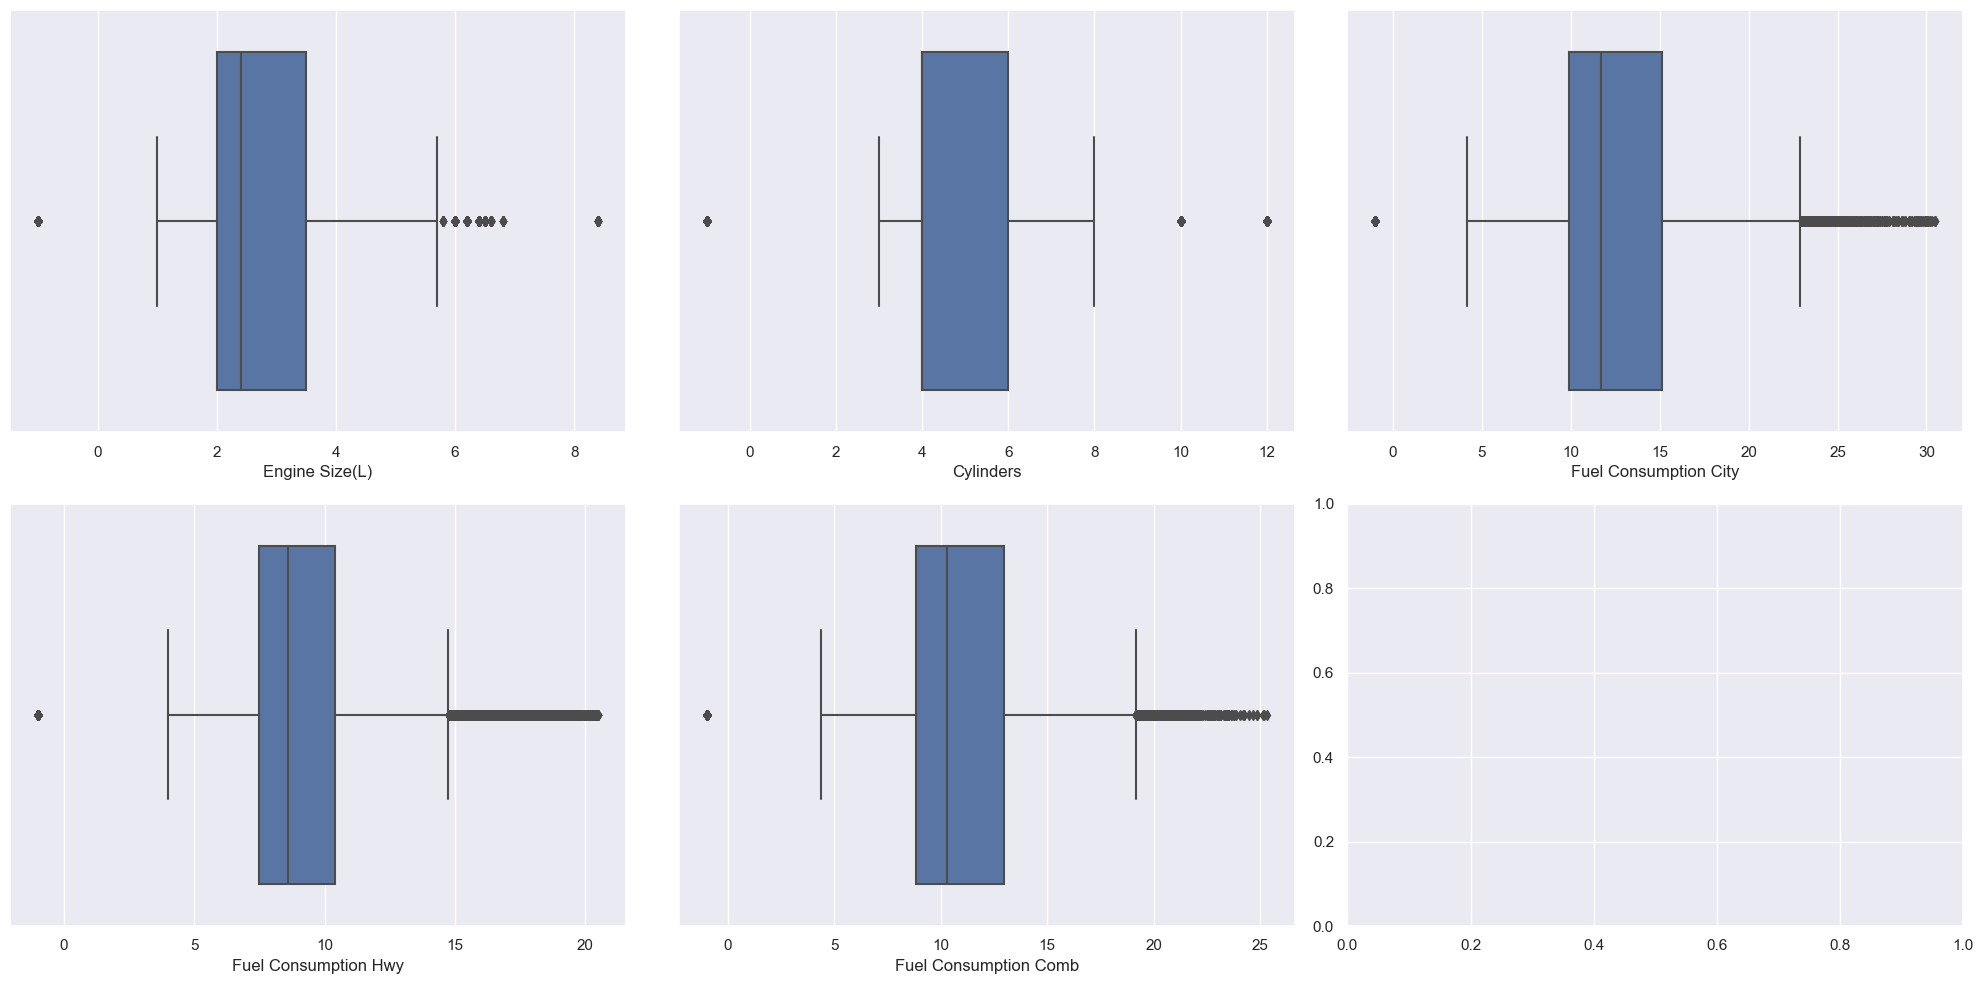

In [ ]:
# check outliers
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

for i, col in enumerate(num_cols):
    sns.boxplot(x=col, data=converted_train_df, ax=axes[i // 3, i % 3])
plt.tight_layout()
plt.show()

Terlihat cukup banyak outlier! Mari coba kita cek persebaran pada test dataset, jika persebaran mirip antara train dan test maka menurut kami outlier tidak perlu dihandle.

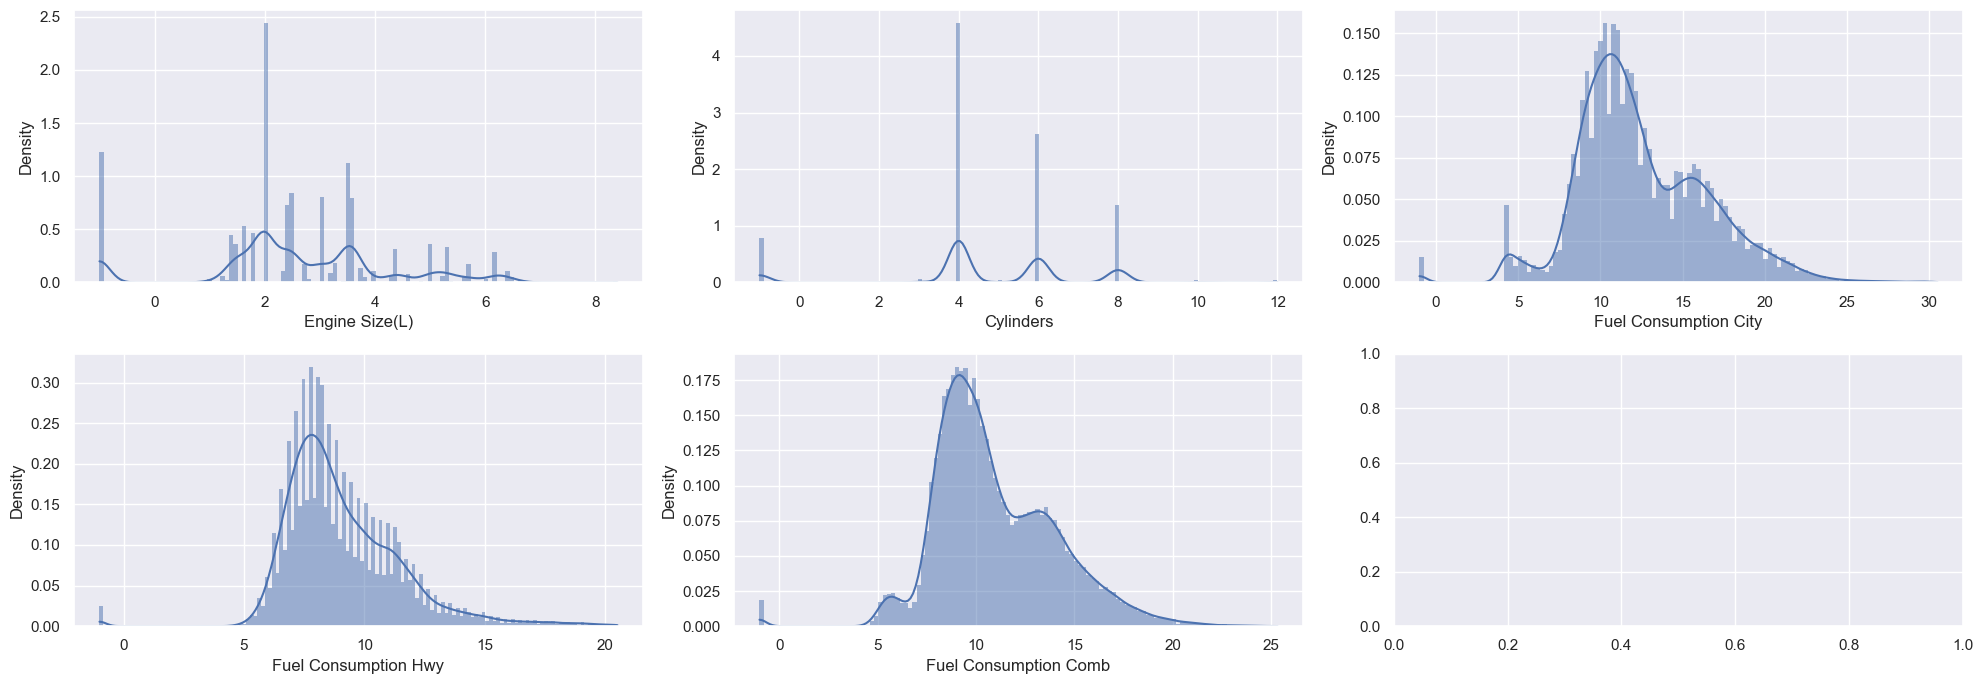

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 7))

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=converted_train_df, ax=axes[i // 3, i % 3], kde=True, stat="density", linewidth=0)
plt.tight_layout()
plt.show()

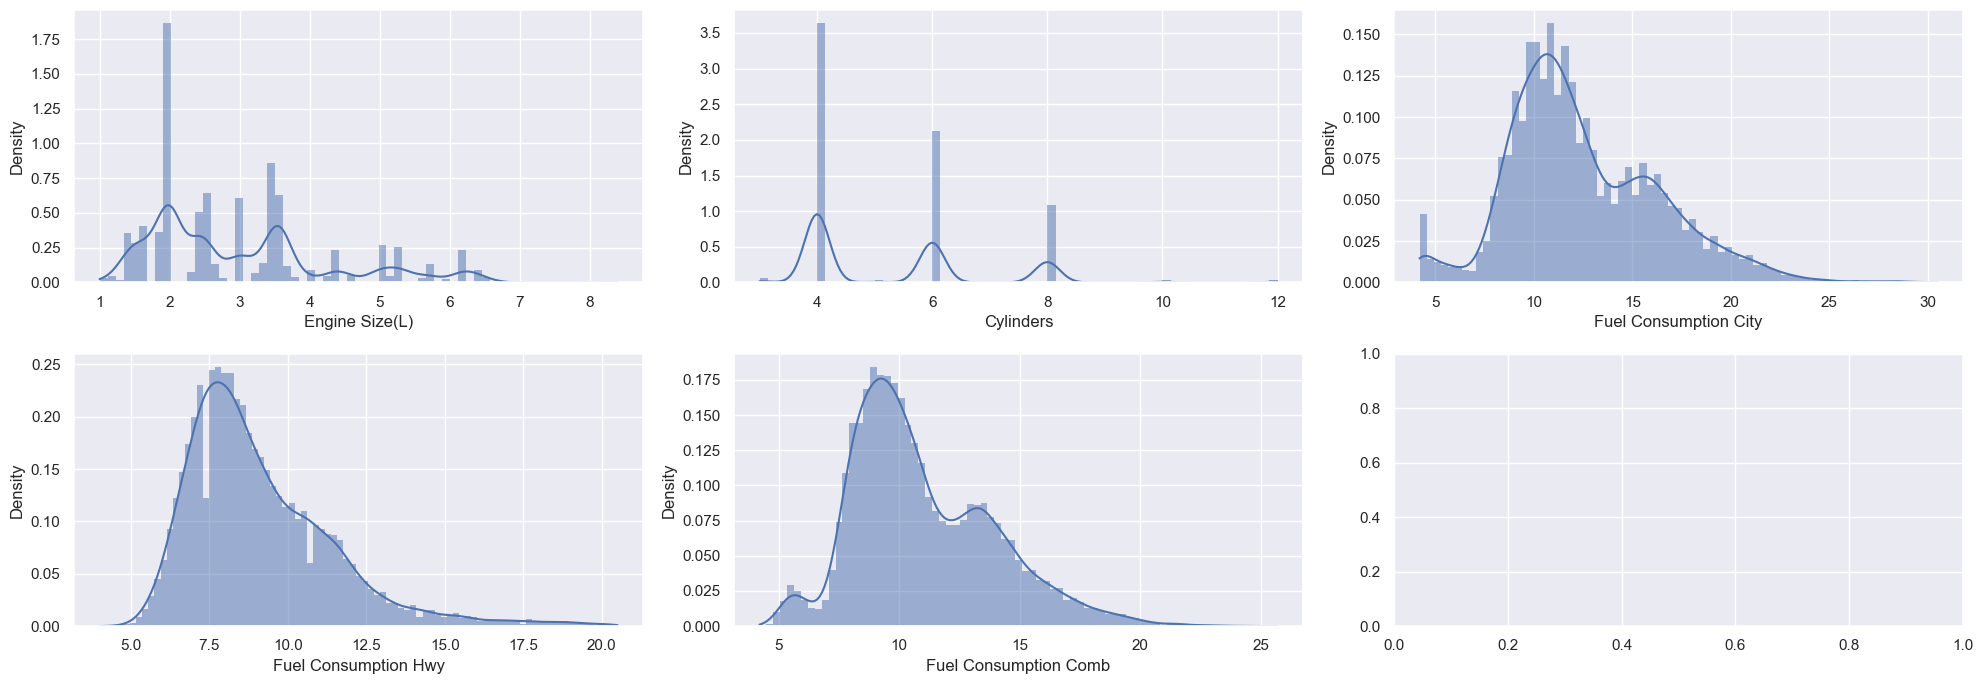

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 7))

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=preprocessing(test_df), ax=axes[i // 3, i % 3], kde=True, stat="density", linewidth=0)
plt.tight_layout()
plt.show()

Persebaran test dan train mirip! Maka kita tidak usah handle outlier di test, dan jika fitting model di train cenderung hasilnya tidak berbeda di test

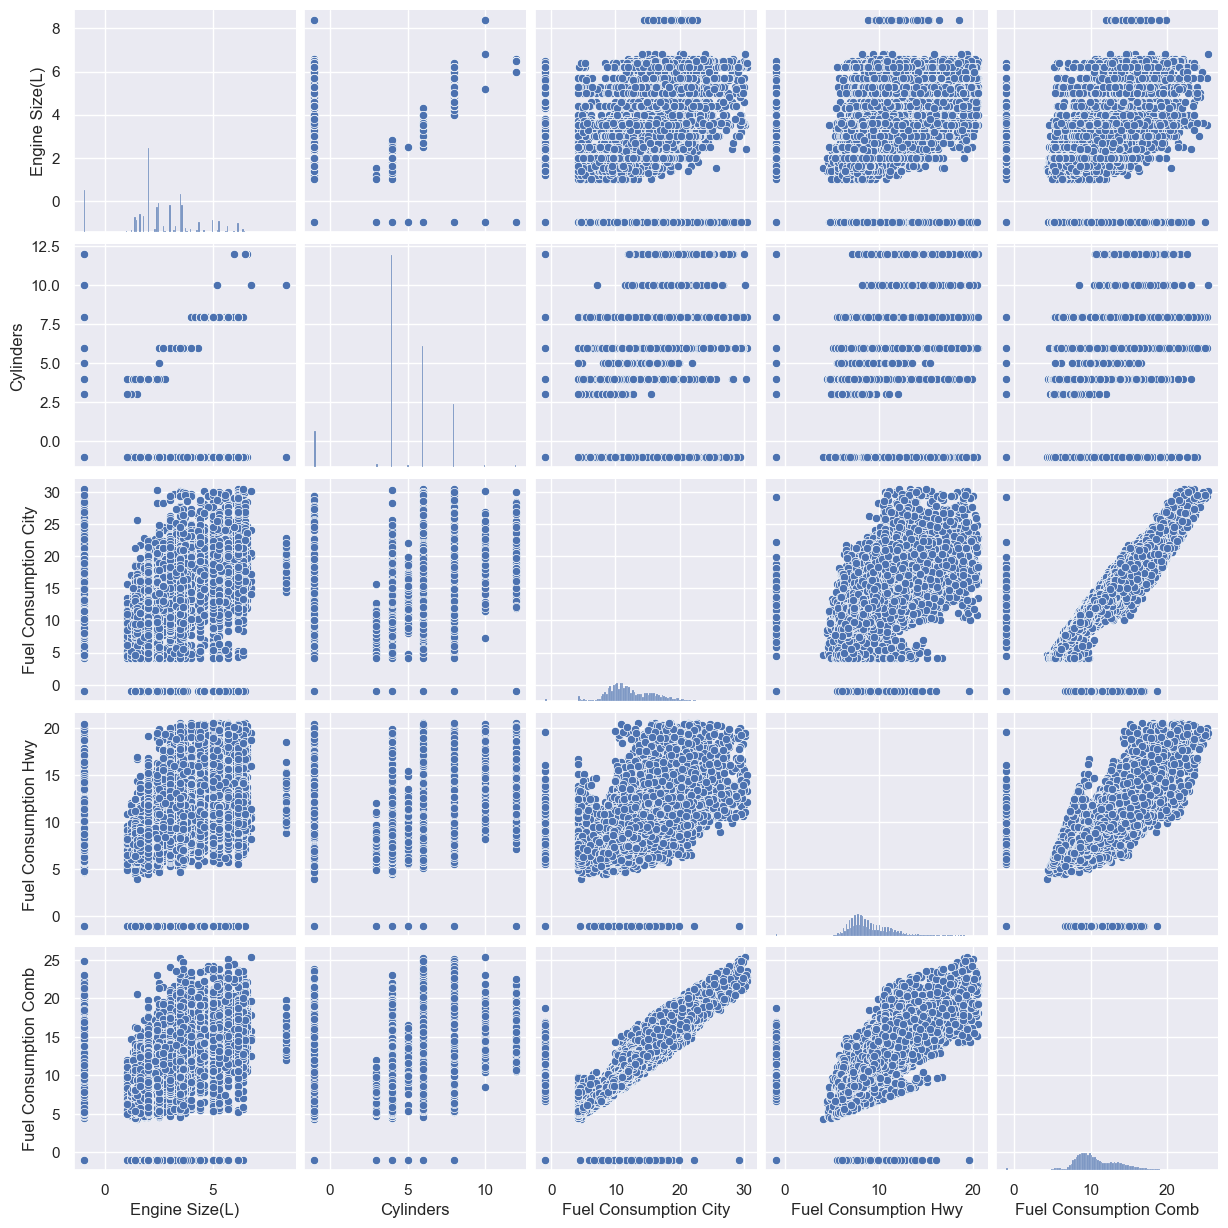

In [ ]:
sns.pairplot(converted_train_df[num_cols])
plt.show()

Fitur-fitur memiliki kecenderungan untuk memiliki hubungan linear, terutama terhadap target variabel. Tetapi karena masih cukup banyak noise dan untuk menghindari multicollinearity kami nanti akan tetap menghindari model linear.

<AxesSubplot: xlabel='Engine Size(L)', ylabel='Cylinders'>

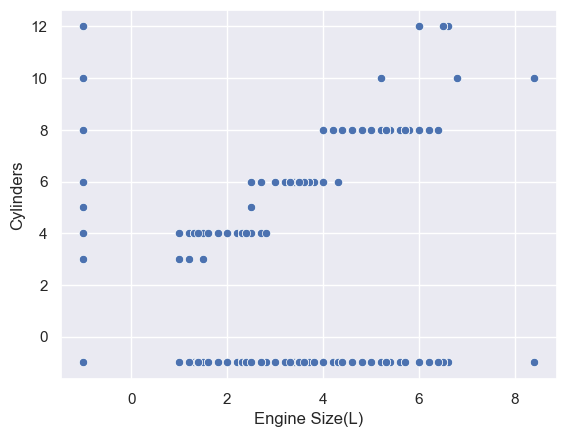

In [ ]:
sns.scatterplot(x=converted_train_df['Engine Size(L)'], y=converted_train_df["Cylinders"])

Engine size dan sylinders memiliki hubungan linear! Nanti kita akan memakai approach untuk meng-impute antara kedua fitur ini dengan model Linear Regression

<AxesSubplot: >

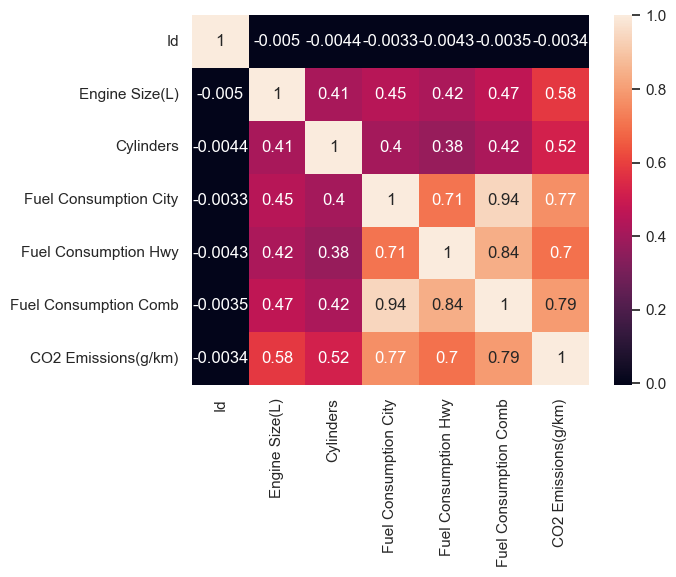

In [ ]:
sns.heatmap(converted_train_df.select_dtypes('number').corr(), annot=True)


Dari analisis heatmap yang kami peroleh, terlihat bahwa hampir semua fitur menunjukkan korelasi yang signifikan dengan target, kecuali kolom 'id'. Oleh karena itu, kami memutuskan untuk menghapus kolom 'id' dari dataset karena tidak memberikan kontribusi yang signifikan terhadap model yang akan dibangun. Selanjutnya, dalam mengidentifikasi masalah multicollinearity, kami menemukan bahwa kolom yang terkait dengan variasi bahan bakar, yaitu 'city', 'hwy', dan 'comb', memiliki hubungan yang erat di antara mereka. Khususnya, karena 'comb' adalah hasil gabungan dari 'city' dan 'hwy', kami memutuskan untuk hanya menggunakan kolom 'city' sebagai fitur dalam model. Tindakan ini diambil untuk menghindari masalah multicollinearity yang dapat mempengaruhi interpretasi dan kinerja model, serta untuk menjaga kesederhanaan model yang akan dibangun. Dengan melakukan penyesuaian ini, kami berharap dapat meningkatkan kualitas dan interpretabilitas dari model prediktif yang akan kami kembangkan.

### Emisi Tertinggi dari masing-masing categorical column

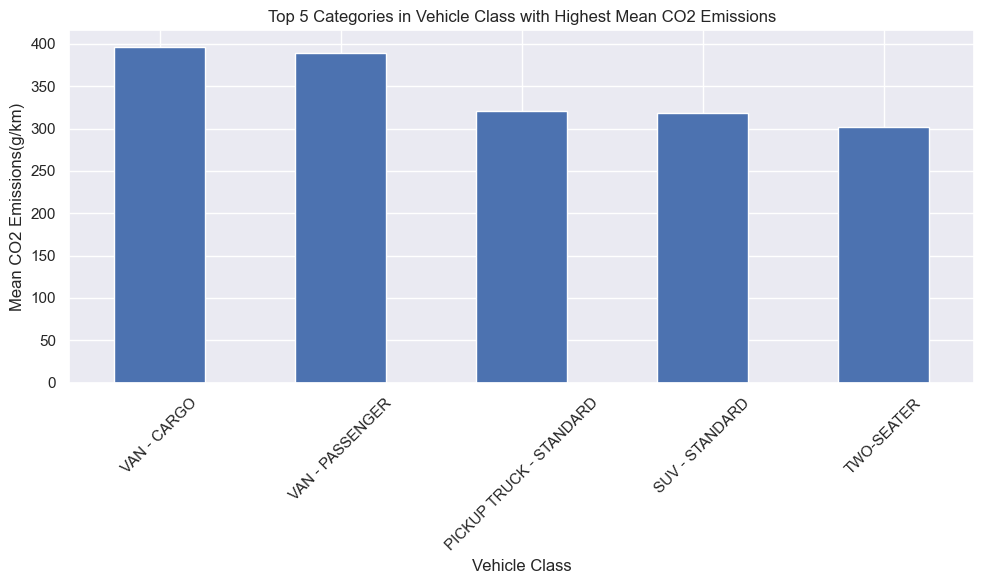

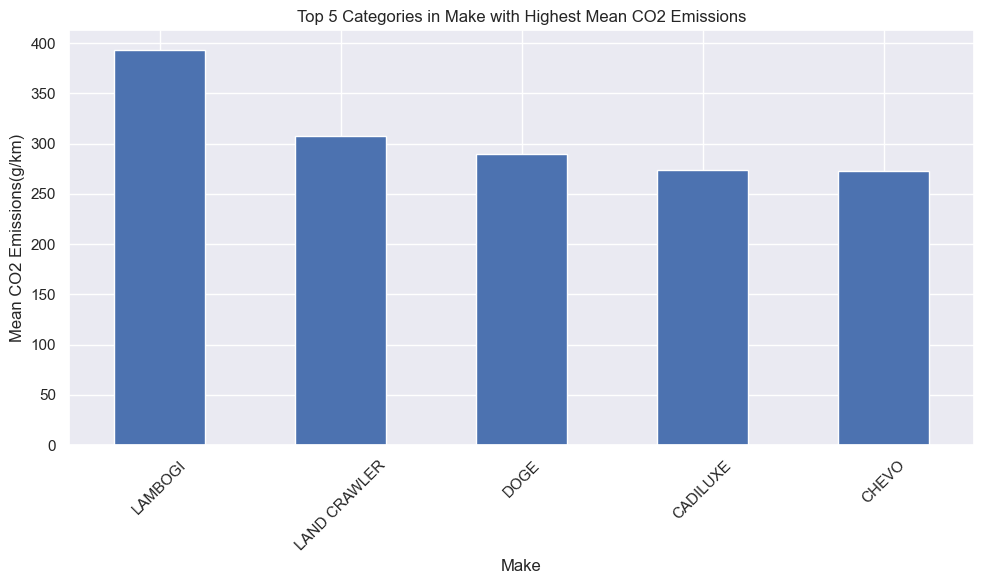

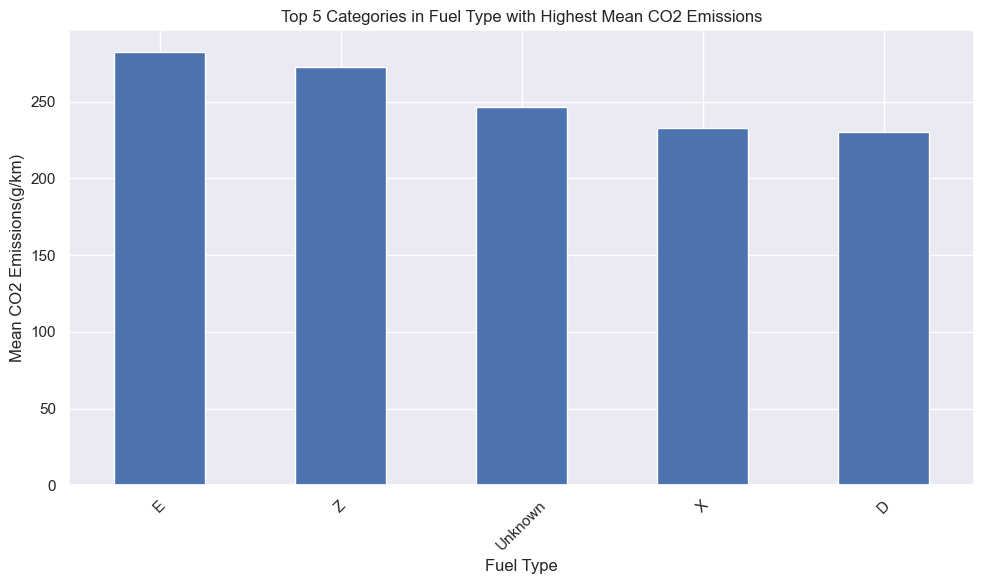

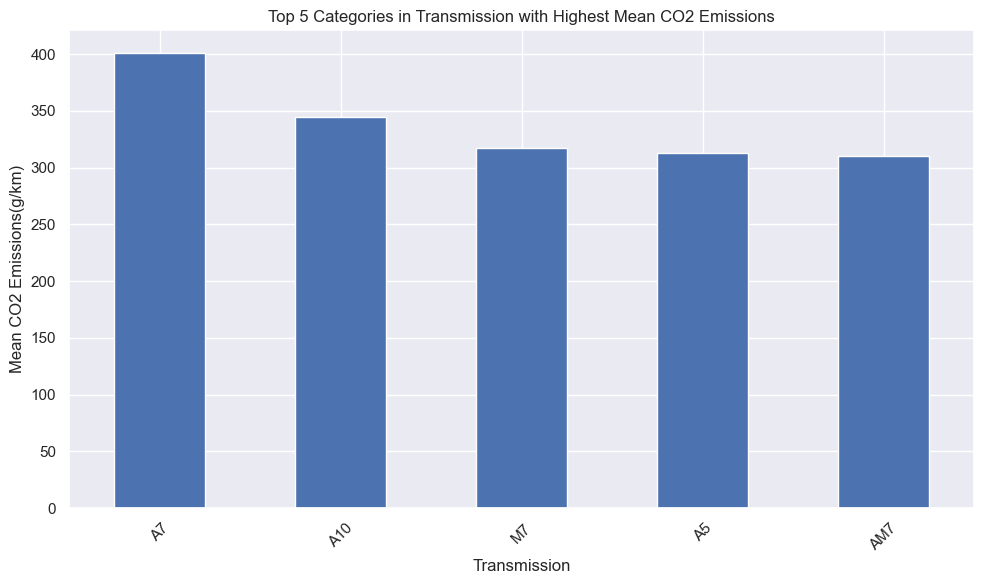

In [ ]:
top_categories = {}
for col in cat_cols:
    mean_co2_by_category = converted_train_df.groupby(col)['CO2 Emissions(g/km)'].mean()
    top_categories[col] = mean_co2_by_category.nlargest(5)  # Getting top 5 categories with the highest mean CO2 Emissions

# Plotting top 5 categories in each categorical column
for col, top_categories_data in top_categories.items():
    plt.figure(figsize=(10, 6))
    top_categories_data.plot(kind='bar')
    plt.title(f'Top 5 Categories in {col} with Highest Mean CO2 Emissions')
    plt.xlabel(col)
    plt.ylabel('Mean CO2 Emissions(g/km)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Dari analisis terhadap data emisi kendaraan, sejumlah wawasan menarik terungkap. Pertama, kendaraan dengan rata-rata emisi tertinggi adalah van kargo. Ini menyoroti perlunya perhatian khusus terhadap pengurangan emisi pada jenis kendaraan ini guna mengurangi dampak lingkungan. Selain itu, dari segi transmisi, kategori A7 menunjukkan emisi tertinggi, mungkin menandakan bahwa jenis transmisi ini dapat menjadi fokus untuk pengembangan teknologi yang lebih ramah lingkungan. Dari perspektif merek, kelompok Lambogi memunculkan emisi rata-rata yang tinggi, yang mungkin memerlukan strategi peningkatan efisiensi atau penggunaan teknologi baru dalam produksinya. Terakhir, dari segi jenis bahan bakar, kendaraan yang menggunakan Ethanol (E85) menunjukkan emisi rata-rata yang signifikan. Hal ini menunjukkan perlunya eksplorasi lebih lanjut terhadap penggunaan bahan bakar alternatif dan dampaknya terhadap lingkungan. Dengan memperoleh wawasan-wawasan ini, langkah-langkah strategis dapat diambil untuk mengurangi emisi kendaraan dan memperbaiki dampak lingkungan dari industri otomotif.

## Target variable analysis

,count,mean,std,min,25%,50%,75%,max,dtypes,unique,missing_count,missing_ratio,raw_type,special_types
CO2 Emissions(g/km),10000,246.7157,67.419362,96.0,198.0,232.0,291.0,520.0,int64,379,,,int,


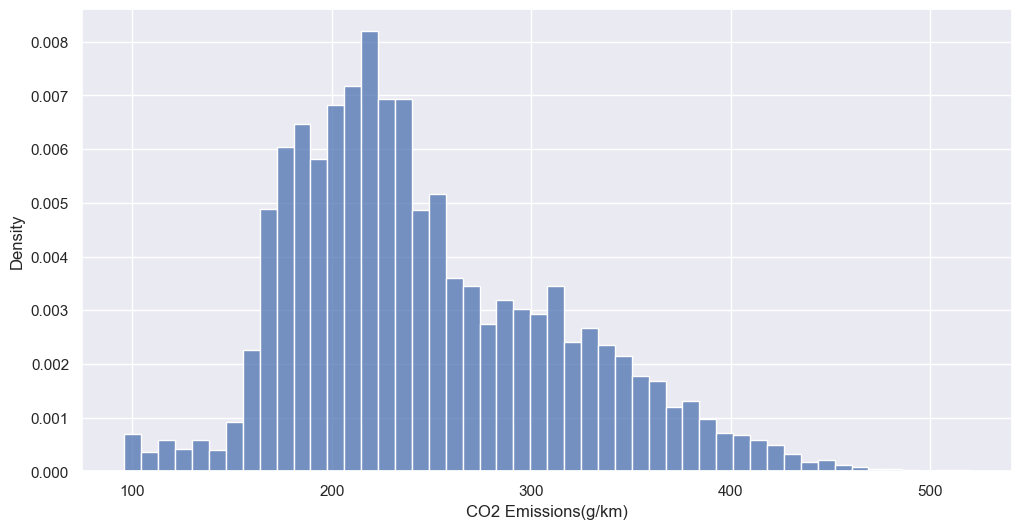

### Distribution fits for target variable
 - ⚠️ none of the [attempted](https://docs.scipy.org/doc/scipy/reference/stats.html#continuous-distributions) distribution fits satisfy specified minimum p-value threshold: `0.01`

### Target variable correlations

**`train_data` - `spearman` correlation matrix; focus: absolute correlation for `CO2 Emissions(g/km)` >= `0.5` (sample size: 10000)**

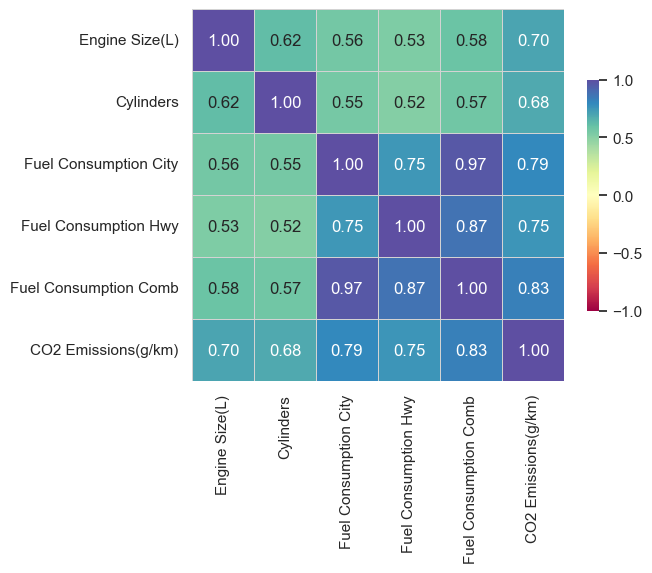

**Feature interaction between `Fuel Consumption Comb`/`CO2 Emissions(g/km)` in `train_data` (sample size: 10000)**

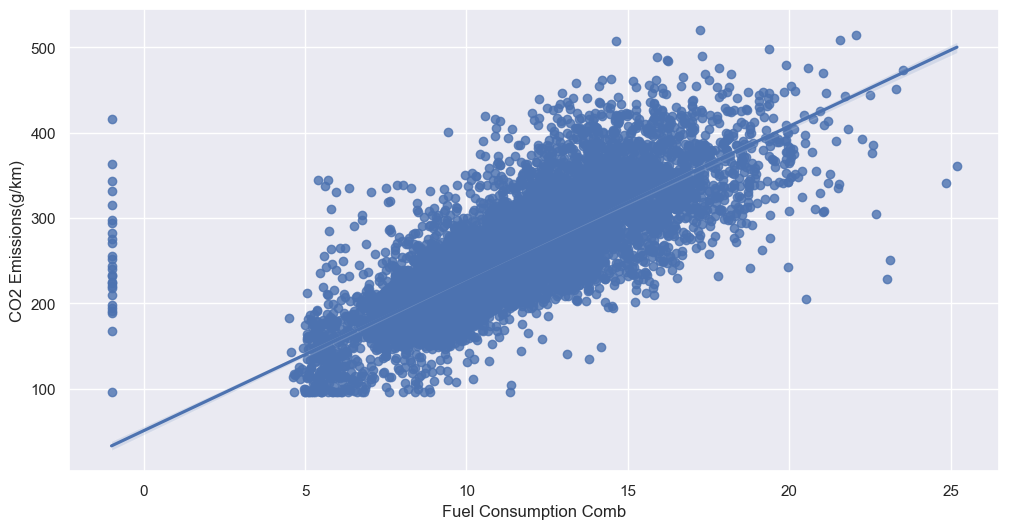

**Feature interaction between `Fuel Consumption City`/`CO2 Emissions(g/km)` in `train_data` (sample size: 10000)**

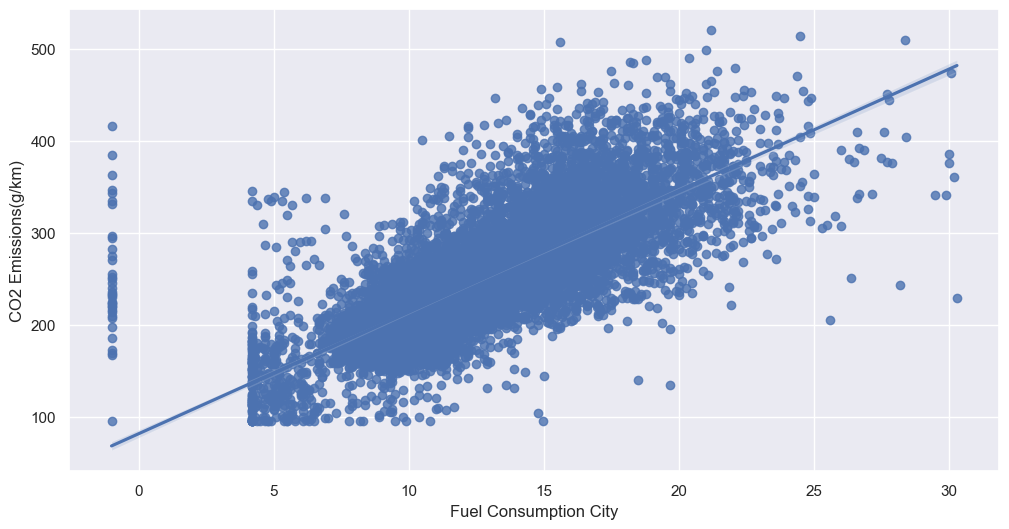

**Feature interaction between `Fuel Consumption Hwy`/`CO2 Emissions(g/km)` in `train_data` (sample size: 10000)**

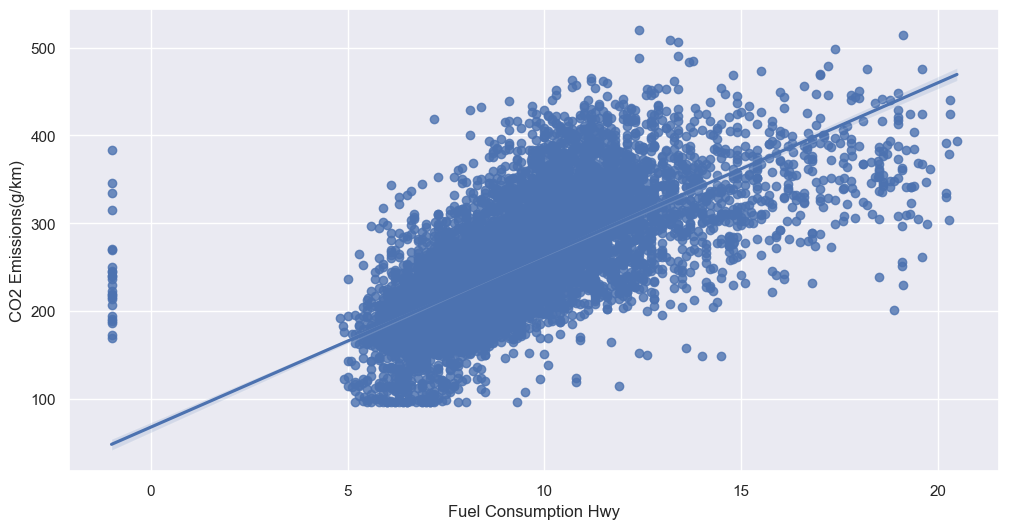

**Feature interaction between `Engine Size(L)`/`CO2 Emissions(g/km)` in `train_data` (sample size: 10000)**

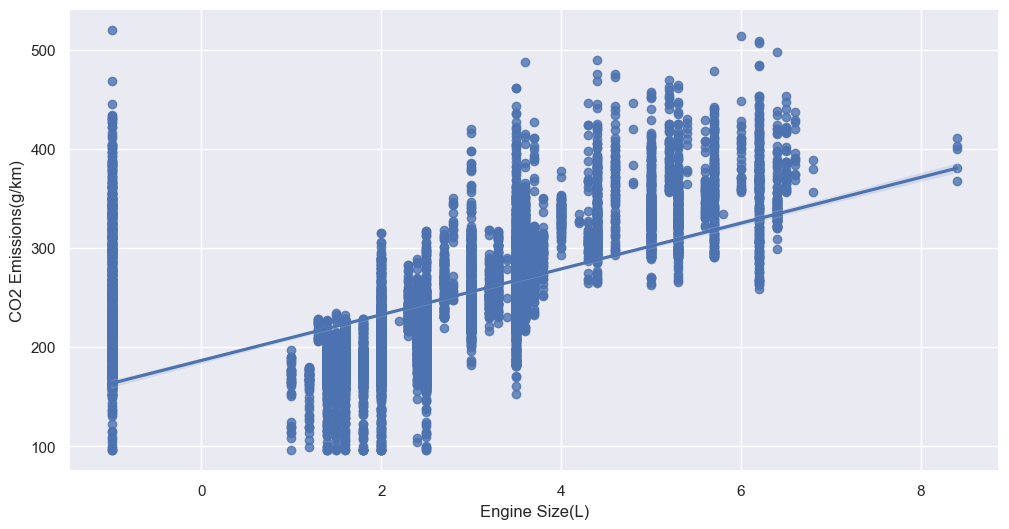

**Feature interaction between `Cylinders`/`CO2 Emissions(g/km)` in `train_data` (sample size: 10000)**

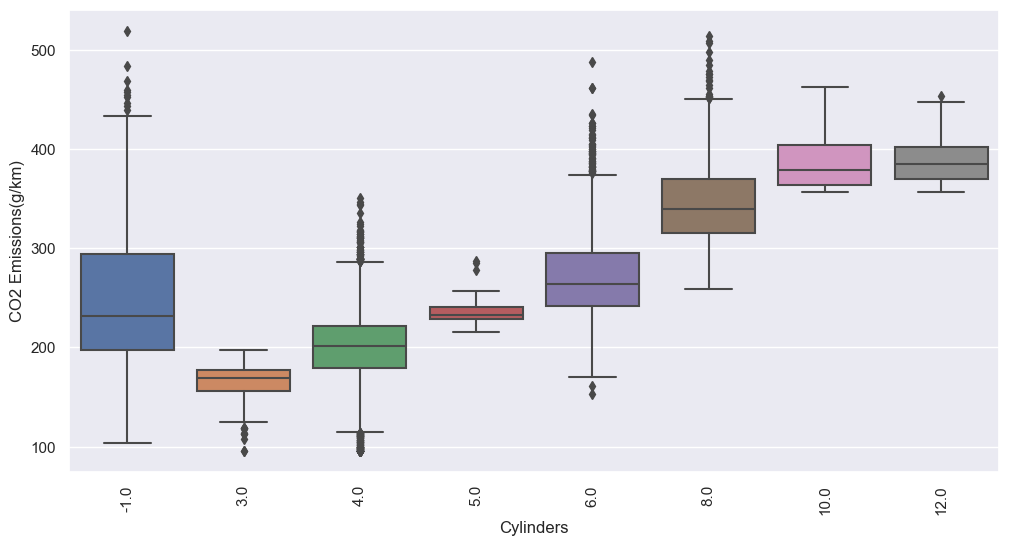

In [ ]:
auto.target_analysis(problem_type="regression", train_data=converted_train_df.drop('Id',axis=1), label='CO2 Emissions(g/km)')

## Modeling (Machine Learning CatBoost)


Pada tahap awal, kami memilih menggunakan model CatBoost sebagai referensi atau baseline untuk analisis kami. Model ini dipilih karena kemampuannya yang kuat dalam menangani berbagai jenis data dan kinerjanya yang baik dalam masalah prediksi. Sebagai model ensemble berbasis gradient boosting, CatBoost memiliki keunggulan dalam menangani data kategorikal tanpa perlu proses one-hot encoding, serta mampu mengatasi overfitting dengan baik.

Dalam penilaian dan evaluasi model CatBoost yang kami lakukan, kami mengadopsi pendekatan cross-validation untuk mengukur kinerja model secara lebih reliabel. Kami membagi dataset menjadi beberapa subset yang saling bersinggungan (folds) dan kemudian melakukan pelatihan dan evaluasi pada setiap fold secara bergantian.

Untuk mengevaluasi model, kami menggunakan metrik Root Mean Square Error (RMSE). RMSE adalah metrik yang umum digunakan dalam masalah regresi untuk mengukur seberapa jauh prediksi model dari nilai sebenarnya. Metrik ini menghitung akar dari rata-rata kuadrat dari selisih antara prediksi model dengan nilai aktual.

Dalam konteks model CatBoost, kami menggunakan pendekatan cross-validation dengan membagi dataset menjadi beberapa fold. Setiap fold digunakan sebagai subset untuk evaluasi dan pelatihan model, sementara fold yang lain digunakan untuk validasi. Kami menghitung RMSE pada setiap iterasi cross-validation dan kemudian melakukan perhitungan rata-rata RMSE dari seluruh fold untuk mendapatkan gambaran yang lebih akurat tentang kinerja model.

Hasil RMSE dari cross-validation menjadi indikator utama untuk menilai seberapa baik model CatBoost yang kami gunakan. Tujuan utama kami adalah untuk meminimalkan RMSE agar model dapat memberikan prediksi yang lebih akurat terhadap data yang belum pernah dilihat sebelumnya.

Dengan pendekatan ini, kami dapat mengukur seberapa baik model bekerja dalam menggeneralisasi pola dari data latih ke data uji yang belum pernah dilihat sebelumnya.

In [ ]:
num_cols = [
    "Engine Size(L)",
    "Cylinders",
    "Fuel Consumption City",
    "Fuel Consumption Hwy",
    "Fuel Consumption Comb",
]

cat_cols = list(
    set(converted_train_df.drop(["Id", "CO2 Emissions(g/km)"], axis=1).columns)
    - set(num_cols)
)

print(f"{len(num_cols)} Numerical columns: {num_cols}")
print(f"{len(cat_cols)} Categorical columns: {cat_cols}")

5 Numerical columns: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City', 'Fuel Consumption Hwy', 'Fuel Consumption Comb']
4 Categorical columns: ['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']


In [ ]:
converted_train_df["High Fuel Consumption"] = (converted_train_df["Fuel Consumption Comb"] > 25).astype(int)
num_cols.append("High Fuel Consumption")

In [ ]:
X = converted_train_df.drop(
    [
        "Id",
        "CO2 Emissions(g/km)",
    ],
    axis=1,
)
y = converted_train_df["CO2 Emissions(g/km)"]
cat_cols = list(set(X.columns) - set(num_cols))
cat_cols

['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']

In [ ]:
X.head()

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,High Fuel Consumption
0,MITSU,SUV - SMALL,1.5,4.0,AV8,X,11.90,7.2,9.80,0
1,TOYOTI,PICKUP TRUCK - SMALL,-1.0,6.0,A5,X,13.79,9.7,11.96,0
2,MATSUDA,COMPACT,2.0,4.0,AS6,X,10.20,7.3,8.89,0
3,CHEVO,VAN - PASSENGER,-1.0,8.0,A6,X,17.30,11.7,14.78,0
4,TOYOTI,COMPACT,1.8,4.0,M6,X,8.10,7.9,8.01,0


Mencoba training dengan menggunakan salah satu state of the art Machine Learning Model yaitu CatBoost

In [ ]:
cb_model = cb.CatBoostRegressor(
    iterations=1500,
    max_depth=8,
    learning_rate=0.03,
    eval_metric="RMSE",
    random_seed=42,
    cat_features=cat_cols,
    task_type="GPU",
    devices="0",
    verbose=0,
)

In [ ]:

cv_scores = cross_val_score(
    cb_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=10,
)

print(f"CV RMSE: {-cv_scores.mean():.2f} +/- {cv_scores.std():.2f}")

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] START .....................................................................
[CV] END .............................. score: (test=-19.893) total time=  48.2s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   48.2s remaining:    0.0s


[CV] END .............................. score: (test=-20.669) total time=  43.7s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  1.5min remaining:    0.0s


[CV] END .............................. score: (test=-19.952) total time=  50.0s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  2.4min remaining:    0.0s


[CV] END .............................. score: (test=-19.822) total time=  49.5s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  3.2min remaining:    0.0s


[CV] END .............................. score: (test=-20.305) total time=  49.0s
CV RMSE: 20.13 +/- 0.32


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.0min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.0min finished


In [ ]:

cv_scores = cross_val_score(
    cb_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=10,
)

print(f"CV RMSE: {-cv_scores.mean():.2f} +/- {cv_scores.std():.2f}")

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] START .....................................................................
[CV] END .............................. score: (test=-19.859) total time=  54.0s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   54.0s remaining:    0.0s


[CV] END .............................. score: (test=-20.453) total time=  49.2s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  1.7min remaining:    0.0s


[CV] END .............................. score: (test=-19.937) total time=  52.3s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  2.6min remaining:    0.0s


[CV] END .............................. score: (test=-19.818) total time=  54.4s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  3.5min remaining:    0.0s


[CV] END .............................. score: (test=-20.371) total time=  49.7s
CV RMSE: 20.09 +/- 0.27


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.3min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.3min finished


In [ ]:

cv_scores = cross_val_score(
    cb_model,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    verbose=10,
)

print(f"CV RMSE: {-cv_scores.mean():.2f} +/- {cv_scores.std():.2f}")

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] START .....................................................................
[CV] END .............................. score: (test=-19.838) total time=  50.4s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   50.4s remaining:    0.0s


[CV] END .............................. score: (test=-20.344) total time=  50.2s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  1.7min remaining:    0.0s


[CV] END .............................. score: (test=-19.968) total time=  48.6s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  2.5min remaining:    0.0s


[CV] END .............................. score: (test=-19.792) total time=  51.0s
[CV] START .....................................................................


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:  3.3min remaining:    0.0s


[CV] END .............................. score: (test=-20.362) total time=  44.3s
CV RMSE: 20.06 +/- 0.25


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.1min remaining:    0.0s
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  4.1min finished


Dapat dilihat setelah beberapa kali dilakukan cross validation, hasilnya tidak jauh berbeda cross validationnya, sehingga model cenderung tidak overfit

In [ ]:
cb_model.fit(X, y)

In [ ]:
import shap
shap.initjs()

In [ ]:
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(converted_train_df.drop(
    [
        "Id",
    ],
    axis=1,
))

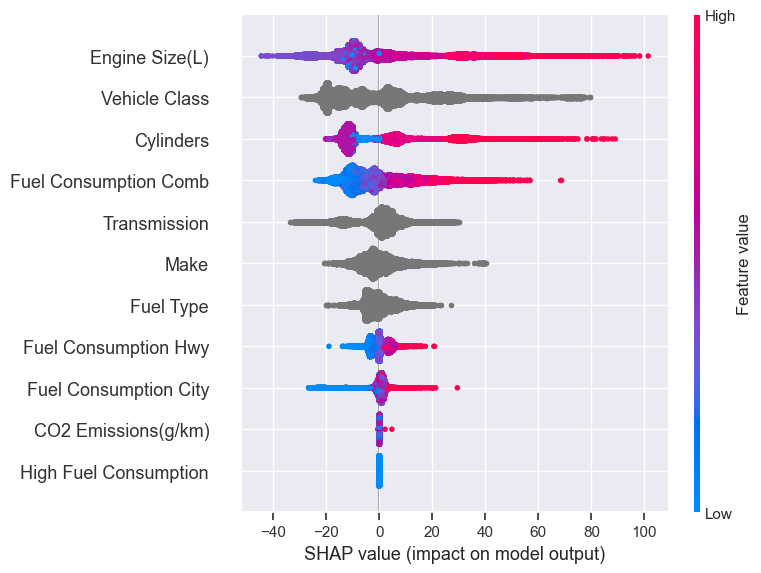

In [ ]:
shap.summary_plot(shap_values, converted_train_df.drop(
    [
        "Id",
    ],
    axis=1,
))

Kami akan menggunakan nilai-nilai SHAP untuk menjelaskan model kami. Menurut model, fitur yang paling berpengaruh dalam menentukan label adalah ukuran mesin (engine size) dan kelas kendaraan (vehicle class). Model kami mengakui bahwa untuk hampir setiap data numerik, semakin tinggi nilai fitur tersebut, semakin tinggi nilai label yang diprediksi. Sesuai dengan analisis korelasi. SHAP tersebut dapat dibaca seperti ini, misal Engine Size (L) semakin ke kanan, feature valuenya semakin besar (semakin warna merah) dan impact on outputnya semakin tinggi. Artinya adalah jika pada data yang akan kita prediksi, fitur Engine Sizenya semakin tinggi, maka hasil CO2 Emissionnya juga semakin tinggi. SHAP ini kita gunakan karena biasanya model itu berupa black box, maka dari itu untuk keperluan interpretability digunakan SHAP.

## AutoGluon

Kami memutuskan untuk menggunakan AutoGluon karena alat ini menjanjikan pendekatan yang efisien dan canggih dalam membangun model prediktif. Kami tertarik dengan kemampuan otomatisasi yang ditawarkan oleh AutoGluon untuk mengeksplorasi berbagai model dan konfigurasi hiperparameter tanpa perlu intervensi manual yang terlalu besar. Dengan menggunakan AutoGluon, kami dapat mempercepat proses pemodelan, meningkatkan efisiensi, dan memungkinkan fokus yang lebih besar pada analisis hasil serta pemahaman yang mendalam terhadap data. Kemudahan penggunaannya menjadi nilai tambah bagi kami, memungkinkan kami untuk fokus pada inti dari permasalahan yang kami hadapi tanpa harus terjebak dalam kompleksitas teknis yang terkait dengan penyetelan model secara manual.

Keunggulan dari AutoGluon adalah kemampuannya dalam mengeksplorasi ruang hiperparameter secara otomatis, menemukan model terbaik, dan mengoptimalkan kinerja model secara efisien. Pendekatan otomatis ini sangat berguna karena dapat mengurangi waktu dan usaha yang dibutuhkan untuk menghasilkan model yang kuat dan unggul.

Dengan peringkat pertama pada leaderboard, hal ini menunjukkan bahwa hasil dari AutoGluon mungkin memiliki beberapa kelebihan dalam hal performa prediktif dan kemampuan generalisasi terhadap data yang belum pernah dilihat sebelumnya. Kemungkinan besar, AutoGluon berhasil mengeksplorasi ruang model dan hiperparameter dengan cara yang lebih efisien, menghasilkan model yang lebih baik daripada baseline atau pendekatan sebelumnya.

Selanjutnya, meskipun peringkat pertama pada leaderboard menunjukkan keunggulan model yang dihasilkan menggunakan AutoGluon, penting untuk terus melakukan evaluasi dan validasi model. Hal ini penting untuk memastikan bahwa model yang dihasilkan dapat diandalkan dan konsisten dalam berbagai situasi.

Dengan demikian, pemantauan dan peningkatan terus-menerus terhadap model AutoGluon yang telah dihasilkan dapat menjadi strategi yang sangat bermanfaat untuk mempertahankan posisi teratas pada leaderboard dan memastikan kualitas prediksi model dalam jangka panjang.

In [ ]:
gluon_train_df = converted_train_df.drop(
    [
        "Id",
        "Fuel Consumption City",
        "Fuel Consumption Hwy",
        # "High Fuel Consumption"
    ],
    axis=1,
).copy()
gluon_train_df.head()

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb,CO2 Emissions(g/km)
0,MITSU,SUV - SMALL,1.5,4.0,AV8,X,9.80,208
1,TOYOTI,PICKUP TRUCK - SMALL,NaN,6.0,A5,X,11.96,325
2,MATSUDA,COMPACT,2.0,4.0,AS6,X,8.89,170
3,CHEVO,VAN - PASSENGER,NaN,8.0,A6,X,14.78,362
4,TOYOTI,COMPACT,1.8,4.0,M6,X,8.01,180


### Gluon 1

Model gluon yang pertama ini, menggunakan semua fitur dan mengisi null dan mengisi null setelah dipreproses dengan naif, yaitu numerik dengan -1 dan categorical dengan unknown.

In [ ]:
# define parameter + training
predictor = TabularPredictor(label="CO2 Emissions(g/km)", eval_metric="root_mean_squared_error", problem_type="regression").fit(
    gluon_train_df,
    presets="best_quality",
)

In [ ]:
results = predictor.fit_summary()
results

*** Summary of fit() ***
Estimated performance of each model:
                          model  score_val              eval_metric  pred_time_val     fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0           WeightedEnsemble_L3 -18.441079  root_mean_squared_error      24.233362  2366.924283                0.002000           1.730424            3       True         28
1          ExtraTreesMSE_BAG_L2 -18.573536  root_mean_squared_error      19.058000  1758.366254                1.751267           8.009635            2       True         18
2               CatBoost_BAG_L2 -18.577190  root_mean_squared_error      17.400303  1906.974671                0.093570         156.618053            2       True         17
3          LightGBM_r131_BAG_L2 -18.580241  root_mean_squared_error      18.420443  1761.395662                1.113710          11.039043            2       True         25
4                XGBoost_BAG_L2 -18.582427  root_mean_squared_error 

{'model_types': {'KNeighborsUnif_BAG_L1': 'StackerEnsembleModel_KNN',
  'KNeighborsDist_BAG_L1': 'StackerEnsembleModel_KNN',
  'LightGBMXT_BAG_L1': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L1': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L1': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L1': 'StackerEnsembleModel_XT',
  'NeuralNetFastAI_BAG_L1': 'StackerEnsembleModel_NNFastAiTabular',
  'XGBoost_BAG_L1': 'StackerEnsembleModel_XGBoost',
  'NeuralNetTorch_BAG_L1': 'StackerEnsembleModel_TabularNeuralNetTorch',
  'LightGBMLarge_BAG_L1': 'StackerEnsembleModel_LGB',
  'CatBoost_r177_BAG_L1': 'StackerEnsembleModel_CatBoost',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel',
  'LightGBMXT_BAG_L2': 'StackerEnsembleModel_LGB',
  'LightGBM_BAG_L2': 'StackerEnsembleModel_LGB',
  'RandomForestMSE_BAG_L2': 'StackerEnsembleModel_RF',
  'CatBoost_BAG_L2': 'StackerEnsembleModel_CatBoost',
  'ExtraTreesMSE_BAG_L2': 'StackerEnsembleModel_

In [ ]:
leaderboard = predictor.leaderboard(converted_train_df)
leaderboard

Dapat dilihat bahwa berikut adalah konfigurasi model terbaiknya

In [ ]:
best_model = predictor.model_best
test_dict = predictor.info()
test_dict

{'path': 'AutogluonModels\\ag-20231211_181730',
 'label': 'CO2 Emissions(g/km)',
 'random_state': 0,
 'version': '1.0.0',
 'features': ['Make',
  'Vehicle Class',
  'Engine Size(L)',
  'Cylinders',
  'Transmission',
  'Fuel Type',
  'Fuel Consumption City',
  'Fuel Consumption Hwy',
  'Fuel Consumption Comb'],
 'feature_metadata_in': <autogluon.common.features.feature_metadata.FeatureMetadata at 0x2dd4199d1c0>,
 'time_fit_preprocessing': 0.2665679454803467,
 'time_fit_training': 2690.7823758125305,
 'time_fit_total': 2691.048943758011,
 'time_limit': 2689,
 'time_train_start': 1702319562.9342058,
 'num_rows_train': 54937,
 'num_cols_train': 9,
 'num_rows_val': None,
 'num_classes': None,
 'problem_type': 'regression',
 'eval_metric': 'root_mean_squared_error',
 'best_model': 'WeightedEnsemble_L3',
 'best_model_score_val': -18.441078947459427,
 'best_model_stack_level': 3,
 'num_models_trained': 28,
 'num_bag_folds': 8,
 'max_stack_level': 3,
 'max_core_stack_level': 2,
 'model_info': {

In [ ]:
best_model

'WeightedEnsemble_L3'

Model terbaik merupakan WeightedEnsemble_L3, di mana digunakan Stacking pada beberapa model. Stacking ini merupakan salah satu cara untuk Ensemble, di mana biasanya single model saja tidak cukup. Penggunaan teknik Ensemble ini biasanya dapat meningkatkan performa karena mempelajari data dari beberapa segi model. Kemudian, dilakukan pembobotan pada setiap model untuk memprediksi suatu data. Oleh karena itu, teknik ini dapat membantu performa kita

In [ ]:
test_dict['model_info']['WeightedEnsemble_L3']['feature_metadata'].to_dict()

{'KNeighborsUnif_BAG_L1': ('float', ('stack',)),
 'KNeighborsDist_BAG_L1': ('float', ('stack',)),
 'LightGBMXT_BAG_L1': ('float', ('stack',)),
 'LightGBM_BAG_L1': ('float', ()),
 'RandomForestMSE_BAG_L1': ('float', ('stack',)),
 'CatBoost_BAG_L1': ('float', ('stack',)),
 'ExtraTreesMSE_BAG_L1': ('float', ('stack',)),
 'NeuralNetFastAI_BAG_L1': ('float', ('stack',)),
 'XGBoost_BAG_L1': ('float', ('stack',)),
 'NeuralNetTorch_BAG_L1': ('float', ('stack',)),
 'LightGBMLarge_BAG_L1': ('float', ()),
 'CatBoost_r177_BAG_L1': ('float', ('stack',)),
 'LightGBMXT_BAG_L2': ('float', ('stack',)),
 'LightGBM_BAG_L2': ('float', ('stack',)),
 'RandomForestMSE_BAG_L2': ('float', ('stack',)),
 'CatBoost_BAG_L2': ('float', ('stack',)),
 'ExtraTreesMSE_BAG_L2': ('float', ('stack',)),
 'NeuralNetFastAI_BAG_L2': ('float', ('stack',)),
 'XGBoost_BAG_L2': ('float', ('stack',)),
 'NeuralNetTorch_BAG_L2': ('float', ('stack',)),
 'LightGBMLarge_BAG_L2': ('float', ('stack',)),
 'CatBoost_r177_BAG_L2': ('float',

In [ ]:
predictor = TabularPredictor.load('ag-20231211_181730')

Dapat dilihat bahwa standardeviasi dari model tidak begitu besar, sehingga model cenderung tidak overfit.

In [ ]:
predictor.feature_importance(converted_train_df.drop('Id', axis=1))

,importance,stddev,p_value,n,p99_high,p99_low
Engine Size(L),20.896088,0.441602,2.392147e-08,5,21.805353,19.986823
Cylinders,15.127458,0.261126,1.064991e-08,5,15.665120,14.589796
Vehicle Class,9.292486,0.436288,5.813953e-07,5,10.190809,8.394163
Transmission,5.807303,0.191612,1.420171e-07,5,6.201834,5.412772
Make,5.678200,0.227841,3.104078e-07,5,6.147327,5.209072
Fuel Type,3.125173,0.243578,4.392650e-06,5,3.626703,2.623642
Fuel Consumption Comb,2.216601,0.223344,1.220324e-05,5,2.676470,1.756732
Fuel Consumption City,1.306530,0.148793,1.984075e-05,5,1.612896,1.000163
Fuel Consumption Hwy,1.199218,0.119529,1.168841e-05,5,1.445331,0.953106


Dapat dilihat di bawah ini, bahwa residual plot dari model cenderung sudah banyak yang 0, tetapi masih ada beberapa residual yang tinggi juga. Hal ini bisa dikarenakan karena pola pada data masih cukup ada yang tidak konsisten, sehingga dapat membuat model bingung dalam mempelajari data.

No path specified. Models will be saved in: "AutogluonModels\ag-20231214_101307\"


### Model Prediction for CO2 Emissions(g/km)

Using validation data for `Test` points

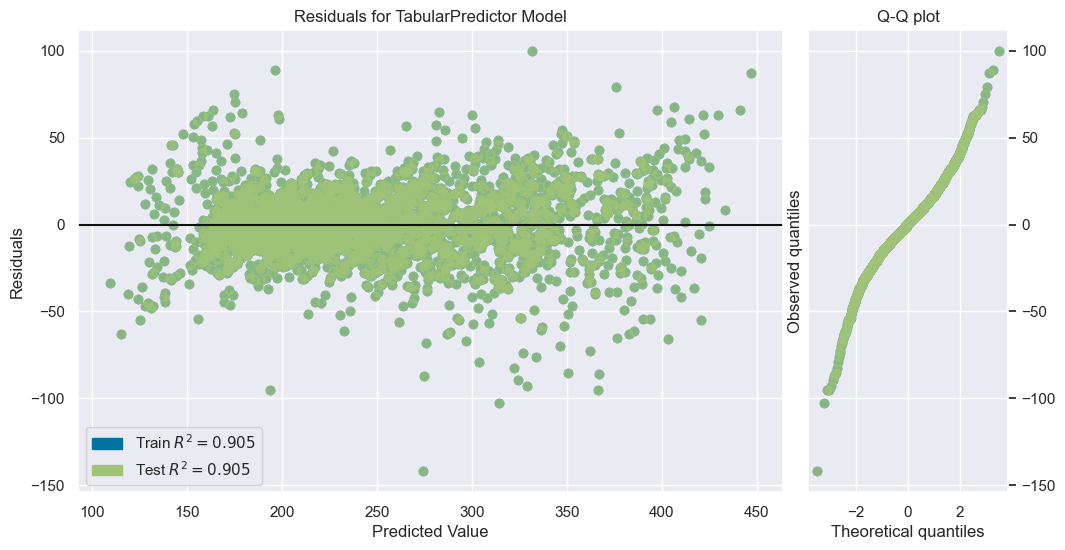

### Model Leaderboard

,model,score_test,score_val,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,-19.933412,-22.660258,0.115063,0.030704,2.881995,0.115063,0.030704,2.881995,1,True,1


### Feature Importance for Trained Model

,importance,stddev,p_value,n,p99_high,p99_low
Engine Size(L),19.966445,0.567532,7.824793e-08,5,21.135002,18.797888
Cylinders,12.714249,0.498536,2.830833e-07,5,13.740741,11.687756
Vehicle Class,9.743401,0.355525,2.123478e-07,5,10.475431,9.011370
Make,5.630023,0.267029,6.054392e-07,5,6.179839,5.080207
Fuel Consumption Comb,5.241495,0.162243,1.100188e-07,5,5.575555,4.907435
Transmission,5.237514,0.064494,2.758533e-09,5,5.370309,5.104720
Fuel Type,3.180774,0.071700,3.096144e-08,5,3.328405,3.033144
Fuel Consumption City,0.488140,0.118007,3.797779e-04,5,0.731118,0.245162
Fuel Consumption Hwy,0.296125,0.095213,1.123168e-03,5,0.492169,0.100081


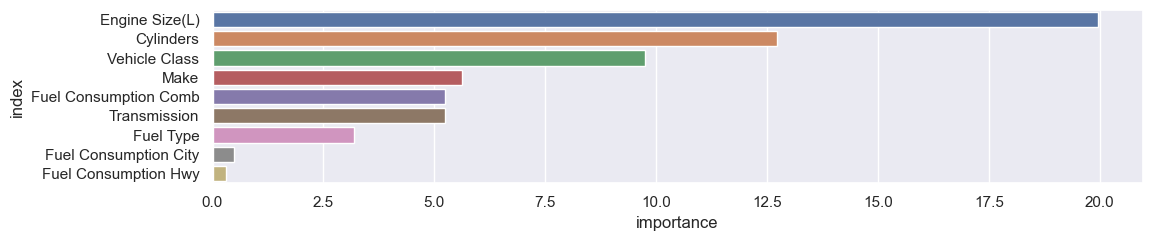

### Rows with the highest prediction error

Rows in this category worth inspecting for the causes of the error

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km),CO2 Emissions(g/km)_pred,error
42651,BMV,SUV - SMALL,3.0,NaN,AS8,Z,14.70,12.71,13.80,416,274.207397,141.792603
11995,CHEVO,COMPACT,6.2,8.0,M6,Z,12.80,11.60,12.26,417,314.515808,102.484192
23475,BMV,SUV - STANDARD,3.0,6.0,AS8,Z,20.00,15.10,17.79,232,331.635468,99.635468
18057,FOLD,VAN - PASSENGER,3.5,6.0,NaN,E,16.39,11.50,14.20,462,366.623962,95.376038
53001,CHEVO,NaN,NaN,NaN,A9,X,12.60,6.30,9.77,289,193.814056,95.185944
45134,FOLD,SUV - STANDARD,3.5,6.0,AS6,X,18.80,10.30,14.97,422,329.192566,92.807434
49798,CHEVO,PICKUP TRUCK - STANDARD,4.3,NaN,A6,X,18.09,10.30,14.59,414,324.359283,89.640717
14758,KIO,NaN,2.4,NaN,AS6,X,5.00,9.50,7.03,108,196.608047,88.608047
50555,BMV,NaN,NaN,6.0,AS8,Z,14.90,11.10,13.19,362,274.763336,87.236664
49625,CHEVO,VAN - PASSENGER,6.0,8.0,A6,X,20.40,18.50,19.55,360,447.077850,87.077850


In [ ]:
state = auto.quick_fit(
    converted_train_df.drop('Id', axis=1),
    'CO2 Emissions(g/km)',
    return_state=True,
    show_feature_importance_barplots=True
)

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb,CO2 Emissions(g/km),CO2 Emissions(g/km)_pred,error
42651,BMV,SUV - SMALL,3.0,NaN,AS8,Z,14.7,12.71,13.8,416,274.207397,141.792603


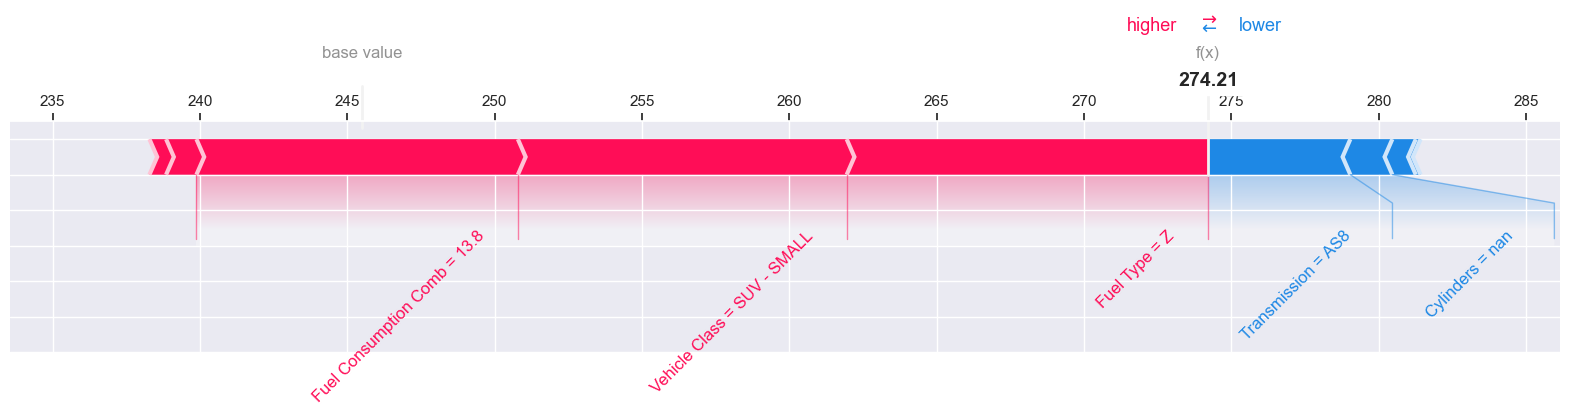

In [ ]:
auto.explain_rows(
    train_data=converted_train_df.drop('Id', axis=1),
    model=state.model,
    display_rows=True,
    rows=state.model_evaluation.highest_error[:1]
)

Di atas merupakan representasi SHAP dari prediksi pada satu baris data di dalam sebuah model prediksi konsumsi bahan bakar kendaraan berdasarkan kelas kendaraan dan jenis bahan bakar yang digunakan. Menurut model ini, kelas kendaraan dan jenis bahan bakar pada baris data tersebut menjadi faktor yang cenderung meningkatkan nilai target atau label yang diprediksi. Namun, faktor-faktor seperti jenis transmisi (transmission) dan jumlah silinder (cylinders) pada baris data tersebut cenderung membuat model cenderung untuk sedikit menurunkan nilai target.

## gluon2

Approach kedua ini memanfaatkan beberapa hasil analisi yang diantaranya: menghilangkan kolom yang mengandung multi collinearity seperti "Fuel Consumption City" dan "Fuel Consumption Hwy" dan juga ada pengisian imputasi menggunakan regresi pada cylinders size(L) melalui fitur engine size (L) karena kedua kolom tersebut memiliki hubungan linear.

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

train = pd.read_csv('train.csv')
converted_train_df = preprocessing(train)

converted_df_copy = converted_train_df.copy()
converted_df_copy.dropna(subset=["Engine Size(L)"], how="all", inplace=True)

df_with_missing = converted_df_copy[converted_df_copy["Cylinders"].isna()]
df_without_missing = converted_df_copy.dropna(subset=["Cylinders"])

X = df_without_missing[["Engine Size(L)"]]
y = df_without_missing["Cylinders"]

regressor = LinearRegression()
regressor.fit(X, y)

predicted_cylinders = regressor.predict(df_with_missing[["Engine Size(L)"]])

converted_train_df.loc[df_with_missing.index, "Cylinders"] = predicted_cylinders

In [ ]:
# The target column is 'CO2 Emissions(g/km)'
target = 'CO2 Emissions(g/km)'

# Specify the column types
feature_types = {
    'Make': 'category',
    'Vehicle Class': 'category',
    'Engine Size(L)': 'float',
    'Cylinders': 'float',
    'Transmission': 'category',
    'Fuel Type': 'category',
    'Fuel Consumption Comb': 'float'
}

train_copy = converted_train_df.copy()[list(feature_types.keys()) + [target]]
# Convert columns to their appropriate types
for column, dtype in feature_types.items():
    train_copy[column] = train_copy[column].astype(dtype)

In [ ]:
# Initialize the TabularPredictor
predictor = TabularPredictor(label=target, eval_metric='root_mean_squared_error',problem_type='regression',)

# Fit the predictor
predictor.fit(
    train_copy,
    presets='best_quality',
    time_limit=4000,
)

In [ ]:
# The target column is 'CO2 Emissions(g/km)'
target = 'CO2 Emissions(g/km)'

# Specify the column types
feature_types = {
    'Make': 'category',
    'Vehicle Class': 'category',
    'Engine Size(L)': 'float',
    'Cylinders': 'float',
    'Transmission': 'category',
    'Fuel Type': 'category',
    'Fuel Consumption Comb': 'float'
}

test_copy = converted_train_df.copy()[list(feature_types.keys())]
# Convert columns to their appropriate types
for column, dtype in feature_types.items():
    test_copy[column] = test_copy[column].astype(dtype)

## Submission

Berikut ini kode untuk membuat submisi. Nilai submisi terbaik kami adalah dengan mengambil rata rata hasil approach gluon 1 dan gluon 2

In [ ]:
test_df = pd.read_csv('dataset/new/test.csv')

In [ ]:
test_df.head()

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb
0,54938,FOLD,PICKUP TRUCK - STANDARD,5.0,8.0,AS10,X,14.20 liters per 100 km,15.20 liters per 100 km,16.06 MPG (AS)
1,54939,BMV,COMPACT,2.0,4.0,A8,Z,9.10 L/100 km,43.46 mpg Imp.,29.66 MPG (AS)
2,54940,JIPU,SUV - SMALL,1.3,4.0,A9,X,27.69 mpg Imp.,7.80 liters per 100 km,9.12 liters per 100 km
3,54941,LECUS,SUV - SMALL,not-recorded,4.0,AS6,Z,NaN,26.43 MPG (AS),NaN
4,54942,BARUSU,COMPACT,2.0,unestablished,M6,Z,11.36 km/L,39.79 mpg Imp.,8.04 L/100km


In [ ]:
test_df = preprocessing(test_df)
test_df.head()

,Id,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City,Fuel Consumption Hwy,Fuel Consumption Comb
0,54938,FOLD,PICKUP TRUCK - STANDARD,5.0,8.0,AS10,X,14.2,15.2,14.65
1,54939,BMV,COMPACT,2.0,4.0,A8,Z,9.1,6.5,7.93
2,54940,JIPU,SUV - SMALL,1.3,4.0,A9,X,10.2,7.8,9.12
3,54941,LECUS,SUV - SMALL,NaN,4.0,AS6,Z,NaN,8.9,NaN
4,54942,BARUSU,COMPACT,2.0,NaN,M6,Z,8.8,7.1,8.04


In [ ]:
test_df.isnull().sum() / test_df.shape[0]

Id                       0.000000
Make                     0.000000
Vehicle Class            0.036653
Engine Size(L)           0.096369
Cylinders                0.080442
Transmission             0.026035
Fuel Type                0.034105
Fuel Consumption City    0.004375
Fuel Consumption Hwy     0.004375
Fuel Consumption Comb    0.004247
dtype: float64

In [ ]:
X_test = test_df[gluon_train_df.drop(["CO2 Emissions(g/km)"], axis=1).columns]
X_test.head()

,Make,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb
0,FOLD,PICKUP TRUCK - STANDARD,5.0,8.0,AS10,X,14.65
1,BMV,COMPACT,2.0,4.0,A8,Z,7.93
2,JIPU,SUV - SMALL,1.3,4.0,A9,X,9.12
3,LECUS,SUV - SMALL,NaN,4.0,AS6,Z,NaN
4,BARUSU,COMPACT,2.0,NaN,M6,Z,8.04


In [ ]:
y_pred = predictor.predict(X_test)

In [ ]:
X_test.columns

Index(['Make', 'Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission',
       'Fuel Type', 'Fuel Consumption Comb', 'High Fuel Consumption'],
      dtype='object')

In [ ]:
submission_df = pd.read_csv("dataset/new/sample_submission.csv")
submission_df["Id"] = test_df["Id"]
submission_df["CO2 Emissions(g/km)"] = y_pred
submission_df.to_csv("submissions/submission11_gluon.csv", index=False)
submission_df.head()

,Id,CO2 Emissions(g/km)
0,54938,335.182373
1,54939,194.955246
2,54940,214.444244
3,54941,228.934357
4,54942,229.733887


# Archived

Pada bagian ini adalah kumpulan percobaan yang kami gunakan tapi tidak mendapatkan hasil yang memuaskan

## Deep Learning + GAN


Kami memilih untuk menguji data yang telah disintesis menggunakan GAN karena panitia mengkonfirmasi bahwa teknik sintesis serupa telah diterapkan pada data tersebut. Dengan mempertimbangkan informasi tersebut, kami melakukan simulasi menggunakan GAN standar yang terdiri dari encoder dan decoder dasar. Pendekatan yang kami ambil adalah menggunakan hasil embedding dari encoder GAN, yang diharapkan dapat digunakan sebagai representasi dalam proses pelatihan deep learning konvensional.

Tujuan kami adalah untuk mengidentifikasi pola khusus yang terkandung dalam data tersebut. Namun, setelah melakukan serangkaian percobaan, kami mengalami kesulitan dalam menemukan pola yang signifikan dalam data. Meskipun demikian, kami mencatat bahwa mesin GAN telah mencapai loss yang tidak dapat ditingkatkan lebih lanjut, menandakan bahwa mesin sudah tidak mungkin untuk dilatih lebih lanjut pada data tersebut. Hal ini mengindikasikan bahwa data sintetis yang digunakan sebelum revisi mungkin memiliki kualitas yang rendah sehingga bahkan GAN mengalami kesulitan saat melatih modelnya.

In [ ]:
train_temp = converted_df.fillna(-1).drop(['Id','Make','Vehicle Class','Fuel Type','Transmission','CO2 Emissions(g/km)',
                                           'Fuel Consumption City','Fuel Consumption Hwy'], axis=1)

In [ ]:
from keras.layers import Input
from keras.layers import Dense
from keras.layers import BatchNormalization
from keras import backend as K


latent_dimension = 16
batch_size = 20
hidden_nodes = 16


input_encoder = Input(shape=(train_temp.shape[1],), name="Input_Encoder")
batch_normalize1 = BatchNormalization()(input_encoder)
hidden_layer = Dense(hidden_nodes, activation="relu", name="Hidden_Encoding")(
    batch_normalize1
)
batch_normalize2 = BatchNormalization()(hidden_layer)
z = Dense(latent_dimension, name="Mean")(batch_normalize2)

In [ ]:
from keras import Model
encoder = Model(input_encoder, z)

In [ ]:
input_decoder = Input(shape=(latent_dimension,), name="Input_Decoder")
batch_normalize1 = BatchNormalization()(input_decoder)
decoder_hidden_layer = Dense(hidden_nodes, activation="relu", name="Hidden_Decoding")(
    batch_normalize1
)
batch_normalize2 = BatchNormalization()(decoder_hidden_layer)
decoded = Dense(train_temp.shape[1], activation="linear", name="Decoded")(batch_normalize2)

In [ ]:
decoder = Model(input_decoder, decoded, name="Decoder")

In [ ]:
encoder_decoder = decoder(encoder(input_encoder))

ae = Model(input_encoder, encoder_decoder)
ae.summary()

In [ ]:
from tensorflow.random import set_seed
import tensorflow as tf

with tf.device('/device:GPU:0'):
  set_seed(2021)
  ae.compile(loss="mean_squared_error", optimizer="adam")
  history = ae.fit(
      train_temp, train_temp, shuffle=True, epochs=1000, batch_size=64, validation_split=0.2, verbose=1
  ).history

Kode di atas adalah simple AutoEncoder yang terdiri dari Encoder dan Decoder biasa untuk mensimulasikan GAN, tetapi karena Loss nya masih tinggi,akan kita buat Deep AutoEncoder di bawah ini

In [ ]:
from sklearn.model_selection import train_test_split
cat_col = ['Id','Make','Vehicle Class','Fuel Type','Transmission',
                                           'Fuel Consumption City','Fuel Consumption Hwy']

train_tmp, test_tmp = train_test_split(integer_df, test_size=0.1, random_state=42)

X_temp = train_tmp.drop(cat_col, axis=1).drop('CO2 Emissions(g/km)', axis=1)
y_temp = train_tmp['CO2 Emissions(g/km)']

X_temp_test = test_tmp.drop(cat_col, axis=1).drop('CO2 Emissions(g/km)', axis=1)
y_temp_test = test_tmp['CO2 Emissions(g/km)']

all_temp = train_temp.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_temp)
X_test = scaler.transform(X_temp_test)
all = scaler.transform(all_temp)

In [ ]:
with tf.device('/device:GPU:0'):
  # Create a TensorFlow model
  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(X_train.shape[1],)),  # Input layer with one feature
      tf.keras.layers.Dense(16, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(1)  # Output layer with one neuron
  ])

  # Compile the model with RMSE as the loss function
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.RootMeanSquaredError()])

  # Train the model
  history = model.fit(X_train, y_temp, epochs=100, validation_data=(X_test, y_temp_test), verbose=1)

In [ ]:
# Evaluate the model
loss, rmse = model.evaluate(X_temp, y_temp_test)
print(f"Root Mean Squared Error on Test Data: {rmse:.4f}")

In [ ]:
from keras import Model
import tensorflow as tf

class Autoencoder(Model):
  def __init__(self, shape):
    super(Autoencoder, self).__init__()
    self.shape = shape
    self.encoder = tf.keras.Sequential([
      tf.keras.layers.Flatten(),
      tf.keras.layers.Dense(16, activation="relu"),
      tf.keras.layers.Dense(16, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(64, activation="relu"),
    ])
    self.decoder = tf.keras.Sequential([
      tf.keras.layers.Dense(tf.math.reduce_prod(shape), activation='sigmoid'),
      tf.keras.layers.Reshape(shape)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded


shape = all_temp.shape[1:]
autoencoder = Autoencoder(shape)

with tf.device('/device:GPU:0'):
  autoencoder.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.RootMeanSquaredError()])

  autoencoder.fit(all_temp, all_temp,
                  epochs=10,
                  shuffle=True,
                  # validation_data=(X_test, X_test),
                  batch_size=64,
                  verbose=1)

Setelah digunakan GAN untuk mensimulasikan pengsintesisan data lebih lanjut, loss yang diperoleh pada model ini cenderung stagnan. Hal ini berarti pola data sulit untuk dipelajari karena terdapat beberapa pola data yang sama sebenarnya tetapi memiliki output yang bertentangan.

In [ ]:
# encoded_train = autoencoder.encoder(X_train).numpy()
encoded_train = encoder(train.drop(['Id','Make','Vehicle Class','Fuel Type','Transmission','CO2 Emissions(g/km)',
                                           'Fuel Consumption City','Fuel Consumption Hwy'], axis=1)).numpy()
encoded_test = encoder(test.drop(['Id','Make','Vehicle Class','Fuel Type','Transmission',
                                           'Fuel Consumption City','Fuel Consumption Hwy'], axis=1)).numpy()
y = train['CO2 Emissions(g/km)']

In [ ]:
with tf.device('/device:GPU:0'):
  # Create a TensorFlow model
  model = tf.keras.Sequential([
      tf.keras.layers.Input(shape=(encoded_train.shape[1],)),  # Input layer with one feature
      tf.keras.layers.Dense(16, activation="relu"),
      tf.keras.layers.Dense(32, activation="relu"),
      tf.keras.layers.Dense(1)  # Output layer with one neuron
  ])

  # Compile the model with RMSE as the loss function
  model.compile(optimizer='adam', loss='mean_squared_error', metrics=[tf.keras.metrics.RootMeanSquaredError()])

  # Train the model
  history = model.fit(encoded_train, y, epochs=100, batch_size=32, validation_split=0.2, verbose=1)

Kita juga mencoba model deep learning, tetapi data tabular masih lebih baik direpresentasikan dengan model machine learning, seperti yang telah didefinisikan di atas. Sehingga pada bagian GAN dan Deep Learning ini tidak jadi kita pakai. Beberapa paper juga menyebutkan bahwa model Machine Learning cenderung bekerja lebih baik pada data tabular dibandingkan model Deep Learning.